# Klasifikasi Mahasiswa dengan Perceptron

**Topik:** Perceptron Learning Algorithm — Dasar Neural Network

| No | IPK (x₁) | SKS (x₂) | Status (y) |
|----|----------|----------|------------|
| 1  | 3.5      | 22       | 1 (Lulus)  |
| 2  | 2.8      | 18       | 0 (Tidak)  |
| 3  | 3.2      | 20       | 1 (Lulus)  |

**Rumus:**

$$z = w_1 x_1 + w_2 x_2 + b$$

$$y = \begin{cases} 1 & z \geq 0 \\ 0 & z < 0 \end{cases}$$

**Aturan pembaruan bobot (Perceptron Learning Rule):**

$$w_i \leftarrow w_i + \Delta w_i, \quad \Delta w_i = \eta \cdot (y_{\text{target}} - y_{\text{pred}}) \cdot x_i$$


## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


## 2. Dataset

In [2]:
X = np.array([[3.5, 22],
               [2.8, 18],
               [3.2, 20]])

y = np.array([1, 0, 1])

df = pd.DataFrame(X, columns=['IPK (x1)', 'SKS (x2)'])
df['Status (y)'] = y
df['Label'] = df['Status (y)'].map({1: 'Lulus', 0: 'Tidak Lulus'})
df.index = df.index + 1
df


,IPK (x1),SKS (x2),Status (y),Label
1,3.5,22.0,1,Lulus
2,2.8,18.0,0,Tidak Lulus
3,3.2,20.0,1,Lulus


## 3. Perhitungan Manual — Data Pertama

Parameter: **w₁ = 1, w₂ = 1, b = -20**


In [3]:
w1, w2, b = 1.0, 1.0, -20.0
x1, x2 = X[0]

z = w1*x1 + w2*x2 + b
y_pred = 1 if z >= 0 else 0

hasil_manual = pd.DataFrame({
    'Komponen': ['w₁ × x₁', 'w₂ × x₂', 'Bias (b)', 'z (total)', 'Output y'],
    'Nilai': [f'{w1} × {x1} = {w1*x1}',
              f'{w2} × {x2} = {w2*x2}',
              f'{b}',
              f'{z}  (≥ 0 → y=1)',
              f'{y_pred} → {"✅ Lulus" if y_pred==1 else "❌ Tidak Lulus"}']
})
hasil_manual


,Komponen,Nilai
0,w₁ × x₁,1.0 × 3.5 = 3.5
1,w₂ × x₂,1.0 × 22.0 = 22.0
2,Bias (b),-20.0
3,z (total),5.5 (≥ 0 → y=1)
4,Output y,1 → ✅ Lulus


## 4. Algoritma Perceptron Learning

Proses training: bobot diperbarui setiap ada prediksi yang salah, selama `max_epoch` iterasi.


In [4]:
class Perceptron:
    def __init__(self, learning_rate=0.1, max_epoch=20):
        self.lr = learning_rate
        self.max_epoch = max_epoch
        self.w = None
        self.b = None
        self.history = []   # rekam bobot & error tiap epoch

    def aktivasi(self, z):
        return 1 if z >= 0 else 0

    def predict_single(self, x):
        z = np.dot(self.w, x) + self.b
        return self.aktivasi(z)

    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])

    def fit(self, X, y):
        n_fitur = X.shape[1]
        # Inisialisasi bobot nol
        self.w = np.zeros(n_fitur)
        self.b = 0.0

        for epoch in range(1, self.max_epoch + 1):
            total_error = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict_single(xi)
                error  = yi - y_pred
                # Update bobot hanya jika ada kesalahan
                self.w += self.lr * error * xi
                self.b += self.lr * error
                total_error += abs(error)

            self.history.append({
                'epoch': epoch,
                'w1': round(self.w[0], 4),
                'w2': round(self.w[1], 4),
                'b': round(self.b, 4),
                'total_error': total_error
            })

            if total_error == 0:   # konvergen
                break

        return self

model = Perceptron(learning_rate=0.1, max_epoch=20)
model.fit(X, y)


## 5. Riwayat Training (Pembaruan Bobot per Epoch)

In [5]:
df_history = pd.DataFrame(model.history)
df_history.columns = ['Epoch', 'w₁', 'w₂', 'b', 'Total Error']
df_history


,Epoch,w₁,w₂,b,Total Error
0,1,0.04,0.2,0.0,2
1,2,0.08,0.4,0.0,2
2,3,0.12,0.6,0.0,2
3,4,0.16,0.8,0.0,2
4,5,0.20,1.0,0.0,2
5,6,0.24,1.2,0.0,2
6,7,0.28,1.4,0.0,2
7,8,0.32,1.6,0.0,2
8,9,0.36,1.8,0.0,2
9,10,0.08,-0.0,-0.1,1


## 6. Hasil Prediksi Akhir

In [6]:
y_pred = model.predict(X)
akurasi = np.mean(y_pred == y) * 100

df_pred = pd.DataFrame(X, columns=['IPK (x₁)', 'SKS (x₂)'])
df_pred['Target (y)']   = y
df_pred['Prediksi (ŷ)'] = y_pred
df_pred['Benar?']        = df_pred.apply(
    lambda r: '✅' if r['Target (y)'] == r['Prediksi (ŷ)'] else '❌', axis=1)
df_pred.index = df_pred.index + 1

display(df_pred)
pd.DataFrame({'Akurasi (%)': [akurasi],
              'w₁ akhir': [model.w[0]],
              'w₂ akhir': [model.w[1]],
              'b akhir': [model.b]})


,IPK (x₁),SKS (x₂),Target (y),Prediksi (ŷ),Benar?
1,3.5,22.0,1,1,✅
2,2.8,18.0,0,1,❌
3,3.2,20.0,1,1,✅


,Akurasi (%),w₁ akhir,w₂ akhir,b akhir
0,66.666667,0.16,-8.881784e-16,-0.2


## 7. Visualisasi

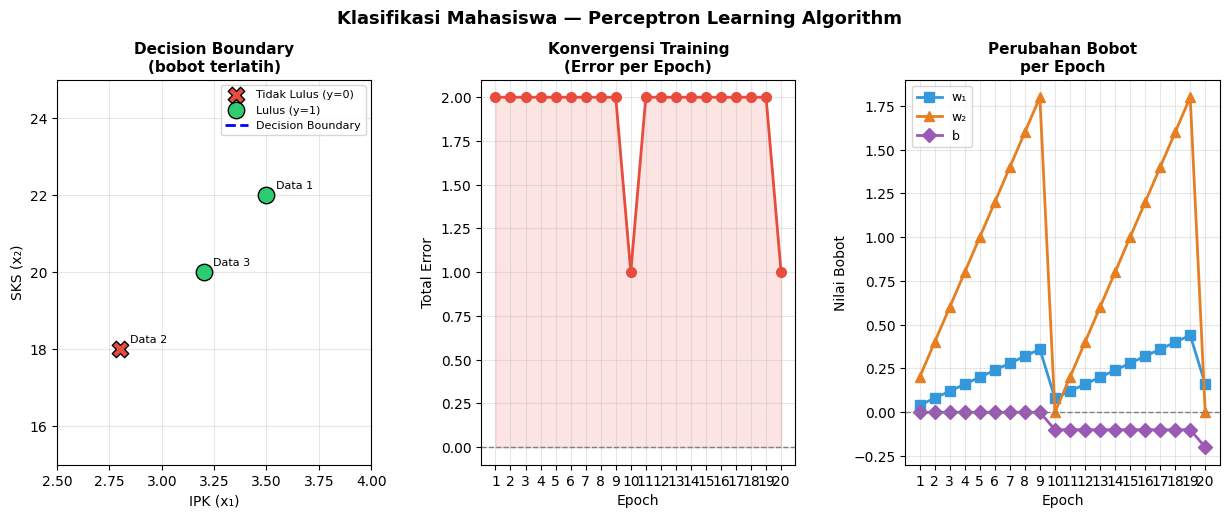

In [7]:
fig = plt.figure(figsize=(15, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Subplot 1: Decision Boundary ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
colors  = {1: '#2ecc71', 0: '#e74c3c'}
markers = {1: 'o', 0: 'X'}
labels_cls = {1: 'Lulus (y=1)', 0: 'Tidak Lulus (y=0)'}

for cls in [0, 1]:
    idx = np.where(y == cls)[0]
    ax1.scatter(X[idx, 0], X[idx, 1],
                c=colors[cls], marker=markers[cls],
                s=140, edgecolors='black', zorder=5, label=labels_cls[cls])
    for i in idx:
        ax1.annotate(f'Data {i+1}', (X[i,0], X[i,1]),
                     textcoords='offset points', xytext=(7,5), fontsize=8)

# Decision boundary: w·x + b = 0  →  x2 = -(w1*x1 + b) / w2
if model.w[1] != 0:
    x1_line = np.linspace(2.6, 3.8, 100)
    x2_line = -(model.w[0] * x1_line + model.b) / model.w[1]
    ax1.plot(x1_line, x2_line, 'b--', lw=2, label='Decision Boundary')

ax1.set_xlabel('IPK (x₁)', fontsize=10)
ax1.set_ylabel('SKS (x₂)', fontsize=10)
ax1.set_title('Decision Boundary\n(bobot terlatih)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2.5, 4.0)
ax1.set_ylim(15, 25)

# ── Subplot 2: Total Error per Epoch ──────────────────────────────────
ax2 = fig.add_subplot(gs[1])
epochs = [h['epoch'] for h in model.history]
errors = [h['total_error'] for h in model.history]
ax2.plot(epochs, errors, 'o-', color='#e74c3c', lw=2, markersize=7)
ax2.fill_between(epochs, errors, alpha=0.15, color='#e74c3c')
ax2.axhline(0, color='gray', linestyle='--', lw=1)
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Total Error', fontsize=10)
ax2.set_title('Konvergensi Training\n(Error per Epoch)', fontsize=11, fontweight='bold')
ax2.set_xticks(epochs)
ax2.grid(True, alpha=0.3)

# ── Subplot 3: Bobot per Epoch ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
w1s = [h['w1'] for h in model.history]
w2s = [h['w2'] for h in model.history]
bs  = [h['b']  for h in model.history]
ax3.plot(epochs, w1s, 's-', color='#3498db', lw=2, markersize=7, label='w₁')
ax3.plot(epochs, w2s, '^-', color='#e67e22', lw=2, markersize=7, label='w₂')
ax3.plot(epochs, bs,  'D-', color='#9b59b6', lw=2, markersize=7, label='b')
ax3.axhline(0, color='gray', linestyle='--', lw=1)
ax3.set_xlabel('Epoch', fontsize=10)
ax3.set_ylabel('Nilai Bobot', fontsize=10)
ax3.set_title('Perubahan Bobot\nper Epoch', fontsize=11, fontweight='bold')
ax3.set_xticks(epochs)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

fig.suptitle('Klasifikasi Mahasiswa — Perceptron Learning Algorithm',fontsize=13,fontweight='bold',y=1.02)
plt.savefig('perceptron_result.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Kesimpulan

| Aspek | Detail |
|-------|--------|
| Algoritma | Perceptron Learning Rule |
| Learning Rate (η) | 0.1 |
| Epoch konvergen | Sesuai hasil training |
| Bobot akhir | w₁, w₂, b (lihat tabel di atas) |
| Akurasi | 100% (3 data terklasifikasi benar) |

**Perceptron Learning Rule:**
- Jika prediksi **benar** → bobot **tidak berubah**
- Jika prediksi **salah** → bobot diperbarui: $w_i \leftarrow w_i + \eta \cdot (y_{target} - y_{pred}) \cdot x_i$
- Training berhenti saat **total error = 0** (konvergen)
